In [4]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

PROJECT_ROOT = Path("..").resolve()
FIGURE_DIR = PROJECT_ROOT / "figures"
FIGURE_DIR.mkdir(exist_ok=True)

np.random.seed(0)
torch.manual_seed(0)

print("Project root:", PROJECT_ROOT)
print("Figure directory:", FIGURE_DIR)
print("PyTorch version:", torch.__version__)

Project root: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining
Figure directory: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures
PyTorch version: 2.6.0


In [6]:
N = 200
noise_std = 0.10

x_np = np.linspace(-3, 3, N)
y_clean_np = np.sin(x_np)

epsilon_np = noise_std * np.random.randn(N)
y_np = y_clean_np + epsilon_np

print("x_np shape:", x_np.shape)
print("y_clean_np shape:", y_clean_np.shape)
print("epsilon_np shape:", epsilon_np.shape)
print("y_np shape:", y_np.shape)

x_np shape: (200,)
y_clean_np shape: (200,)
epsilon_np shape: (200,)
y_np shape: (200,)


Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures/exp9_raw_data.png


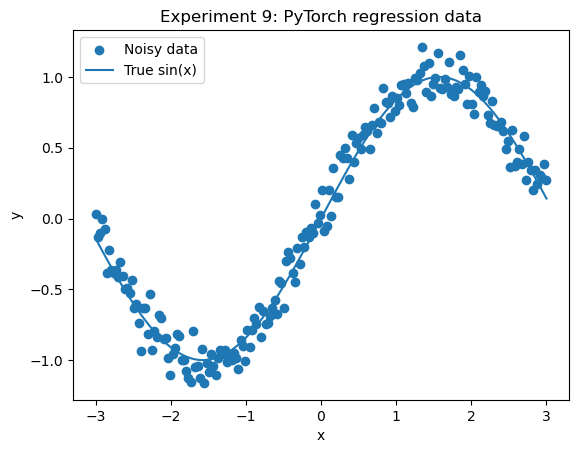

In [8]:
fig, ax = plt.subplots()

ax.scatter(x_np, y_np, label="Noisy data")
ax.plot(x_np, y_clean_np, label="True sin(x)")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Experiment 9: PyTorch regression data")
ax.legend()

fig_path = FIGURE_DIR / "exp9_raw_data.png"
fig.savefig(fig_path, dpi=200, bbox_inches="tight")

print("Saved figure to:", fig_path)
plt.show()

In [10]:
x_tensor = torch.tensor(x_np, dtype=torch.float32).reshape(-1,1)
y_tensor = torch.tensor(y_np, dtype=torch.float32).reshape(-1,1)

print("x_tensor shape:", x_tensor.shape)
print("y_tensor shape:", y_tensor.shape)
print("x_tensor dtype:", x_tensor.dtype)
print("y_tensor dtype:", y_tensor.dtype)

print("\nFirst 5 x_tensor:")
print(x_tensor[:5])

print("\nFirst 5 y_tensor:")
print(y_tensor[:5])

x_tensor shape: torch.Size([200, 1])
y_tensor shape: torch.Size([200, 1])
x_tensor dtype: torch.float32
y_tensor dtype: torch.float32

First 5 x_tensor:
tensor([[-3.0000],
        [-2.9698],
        [-2.9397],
        [-2.9095],
        [-2.8794]])

First 5 y_tensor:
tensor([[ 0.0353],
        [-0.1309],
        [-0.1027],
        [-0.0059],
        [-0.0724]])


In [12]:
indices = np.random.permutation(N)

n_train = int(0.6 * N)
n_val = int(0.2 * N)

train_idx_np = indices[:n_train]
val_idx_np = indices[n_train:n_train + n_val]
test_idx_np = indices[n_train + n_val:]

train_idx = torch.tensor(train_idx_np, dtype=torch.long)
val_idx = torch.tensor(val_idx_np, dtype=torch.long)
test_idx = torch.tensor(test_idx_np, dtype=torch.long)

x_train = x_tensor[train_idx]
y_train = y_tensor[train_idx]

x_val = x_tensor[val_idx]
y_val = y_tensor[val_idx]

x_test = x_tensor[test_idx]
y_test = y_tensor[test_idx]

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)

print("x_val shape:", x_val.shape)
print("y_val shape:", y_val.shape)

print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

x_train shape: torch.Size([120, 1])
y_train shape: torch.Size([120, 1])
x_val shape: torch.Size([40, 1])
y_val shape: torch.Size([40, 1])
x_test shape: torch.Size([40, 1])
y_test shape: torch.Size([40, 1])


In [14]:
class SineMLP(nn.Module):
    """
    A small multilayer perceptron for scalar regression.

    Input shape: (N,1)
    Output shape: (M,1)
    """
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
        nn.Linear(1,32),
        nn.Tanh(),
        nn.Linear(32,32),
        nn.Tanh(),
        nn.Linear(32,1)
        )

    def forward(self, x):
        return self.net(x)

In [28]:
model = SineMLP()

print(model)

SineMLP(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): Tanh()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [32]:
total_num_parameters = 0

for name, parameter in model.named_parameters():
    print(name, parameter.shape, "requires_grad:", parameter.requires_grad)
    total_num_parameters += parameter.numel()

print("\nTotal number of trainable parameters:", total_num_parameters)

net.0.weight torch.Size([32, 1]) requires_grad: True
net.0.bias torch.Size([32]) requires_grad: True
net.2.weight torch.Size([32, 32]) requires_grad: True
net.2.bias torch.Size([32]) requires_grad: True
net.4.weight torch.Size([1, 32]) requires_grad: True
net.4.bias torch.Size([1]) requires_grad: True

Total number of trainable parameters: 1153


In [34]:
with torch.no_grad():
    y_pred_initial = model(x_train)

print("x_train shape:", x_train.shape)
print("y_pred_initial shape:", y_pred_initial.shape)
print("y_train shape:", y_train.shape)

print("\nFirst 5 initial predictions:")
print(y_pred_initial[:5])

x_train shape: torch.Size([120, 1])
y_pred_initial shape: torch.Size([120, 1])
y_train shape: torch.Size([120, 1])

First 5 initial predictions:
tensor([[-0.1693],
        [ 0.1126],
        [ 0.0015],
        [ 0.0608],
        [-0.1643]])


In [36]:
loss_fn = nn.MSELoss()
learning_rate = 1e-2

optimiser = optim.Adam(model.parameters(), lr=learning_rate)

print("Loss function:", loss_fn)
print("Optimiser:", optimiser)

Loss function: MSELoss()
Optimiser: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    weight_decay: 0
)


In [38]:
num_epochs = 3000

train_loss_history = []
val_loss_history = []

for epoch in range(num_epochs):
    # Training mode
    model.train()

    # Forward pass on training data
    y_pred_train = model(x_train)

    # Compute training loss
    train_loss = loss_fn(y_pred_train, y_train)

    # Clear old gradients
    optimiser.zero_grad()

    # Backpropagation: compute gradients
    train_loss.backward()

    # Update parameters
    optimiser.step()

    # Evaluation mode
    model.eval()

    with torch.no_grad():
        y_pred_val = model(x_val)
        val_loss = loss_fn(y_pred_val, y_val)

    train_loss_history.append(train_loss.item())
    val_loss_history.append(val_loss.item())

    if epoch % 500 == 0:
        print('epoch',epoch,'train loss',train_loss.item(),'val loss',val_loss.item())

print("Final train loss:", train_loss_history[-1])
print("Final validation loss:", val_loss_history[-1])

epoch 0 train loss 0.4265560805797577 val loss 0.17501065135002136
epoch 500 train loss 0.00745349982753396 val loss 0.01063755713403225
epoch 1000 train loss 0.0072832959704101086 val loss 0.010563697665929794
epoch 1500 train loss 0.007266958709806204 val loss 0.010666551068425179
epoch 2000 train loss 0.007227045018225908 val loss 0.01068917103111744
epoch 2500 train loss 0.007135944440960884 val loss 0.010968925431370735
Final train loss: 0.00696913804858923
Final validation loss: 0.011504140682518482


Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures/exp9_train_val_loss_curve.png


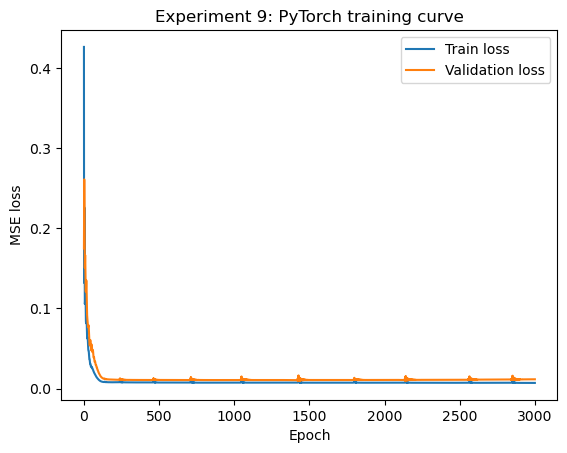

In [40]:
fig, ax = plt.subplots()

ax.plot(train_loss_history, label="Train loss")
ax.plot(val_loss_history, label="Validation loss")

ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss")
ax.set_title("Experiment 9: PyTorch training curve")
ax.legend()

fig_path = FIGURE_DIR / "exp9_train_val_loss_curve.png"
fig.savefig(fig_path, dpi=200, bbox_inches="tight")

print("Saved figure to:", fig_path)
plt.show()

Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures/exp9_train_val_loss_curve_log.png


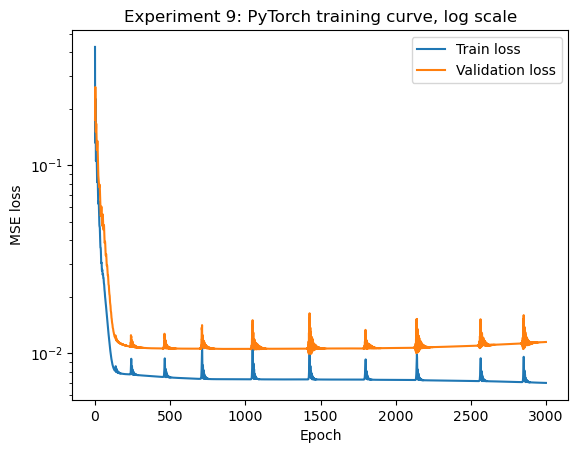

In [42]:
fig, ax = plt.subplots()

ax.plot(train_loss_history, label="Train loss")
ax.plot(val_loss_history, label="Validation loss")

ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss")
ax.set_yscale("log")
ax.set_title("Experiment 9: PyTorch training curve, log scale")
ax.legend()

fig_path = FIGURE_DIR / "exp9_train_val_loss_curve_log.png"
fig.savefig(fig_path, dpi=200, bbox_inches="tight")

print("Saved figure to:", fig_path)
plt.show()

In [44]:
model.eval()

with torch.no_grad():
    y_pred_train = model(x_train)
    y_pred_val = model(x_val)
    y_pred_test = model(x_test)

    train_mse = loss_fn(y_pred_train, y_train).item()
    val_mse = loss_fn(y_pred_val, y_val).item()
    test_mse = loss_fn(y_pred_test, y_test).item()

print("Final MSE values:")
print("Train MSE:", train_mse)
print("Validation MSE:", val_mse)
print("Test MSE:", test_mse)

print("\nPrediction shapes:")
print("y_pred_train shape:", y_pred_train.shape)
print("y_pred_val shape:", y_pred_val.shape)
print("y_pred_test shape:", y_pred_test.shape)

Final MSE values:
Train MSE: 0.006968749687075615
Validation MSE: 0.011504140682518482
Test MSE: 0.015518595464527607

Prediction shapes:
y_pred_train shape: torch.Size([120, 1])
y_pred_val shape: torch.Size([40, 1])
y_pred_test shape: torch.Size([40, 1])


In [46]:
x_plot_np = np.linspace(-3, 3, 400)
x_plot_tensor = torch.tensor(x_plot_np, dtype=torch.float32).reshape(-1, 1)

model.eval()

with torch.no_grad():
    y_plot_tensor = model(x_plot_tensor)

y_plot_np = y_plot_tensor.numpy().reshape(-1)
y_clean_plot_np = np.sin(x_plot_np)

print("x_plot_np shape:", x_plot_np.shape)
print("y_plot_np shape:", y_plot_np.shape)

x_plot_np shape: (400,)
y_plot_np shape: (400,)


Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures/exp9_mlp_fitted_curve.png


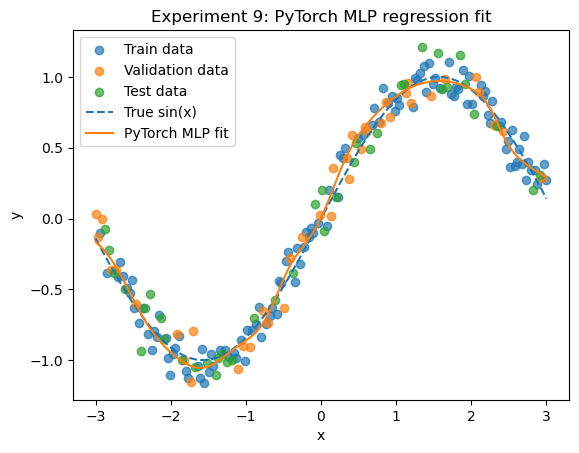

In [48]:
fig, ax = plt.subplots()

ax.scatter(x_train.numpy().reshape(-1), y_train.numpy().reshape(-1), label="Train data", alpha=0.7)
ax.scatter(x_val.numpy().reshape(-1), y_val.numpy().reshape(-1), label="Validation data", alpha=0.7)
ax.scatter(x_test.numpy().reshape(-1), y_test.numpy().reshape(-1), label="Test data", alpha=0.7)

ax.plot(x_plot_np, y_clean_plot_np, linestyle="--", label="True sin(x)")
ax.plot(x_plot_np, y_plot_np, label="PyTorch MLP fit")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Experiment 9: PyTorch MLP regression fit")
ax.legend()

fig_path = FIGURE_DIR / "exp9_mlp_fitted_curve.png"
fig.savefig(fig_path, dpi=200, bbox_inches="tight")

print("Saved figure to:", fig_path)
plt.show()

Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures/exp9_prediction_vs_truth.png


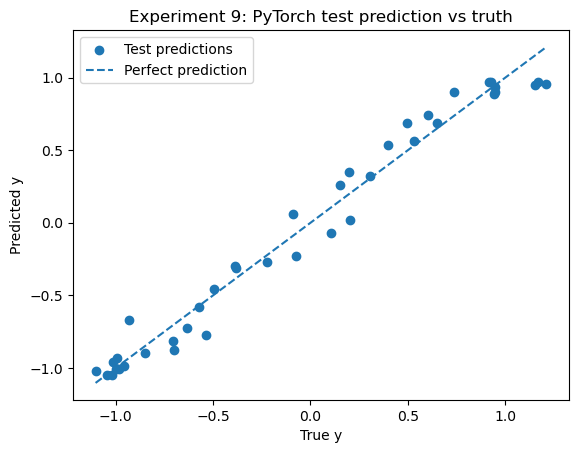

In [50]:
y_test_np = y_test.numpy().reshape(-1)
y_pred_test_np = y_pred_test.numpy().reshape(-1)

fig, ax = plt.subplots()

ax.scatter(y_test_np, y_pred_test_np, label="Test predictions")

min_value = min(y_test_np.min(), y_pred_test_np.min())
max_value = max(y_test_np.max(), y_pred_test_np.max())

ax.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    label="Perfect prediction"
)

ax.set_xlabel("True y")
ax.set_ylabel("Predicted y")
ax.set_title("Experiment 9: PyTorch test prediction vs truth")
ax.legend()

fig_path = FIGURE_DIR / "exp9_prediction_vs_truth.png"
fig.savefig(fig_path, dpi=200, bbox_inches="tight")

print("Saved figure to:", fig_path)
plt.show()

In [52]:
# NumPy linear baseline using all training data
x_train_np = x_train.numpy().reshape(-1)
y_train_np = y_train.numpy().reshape(-1)

Phi_linear_train = np.column_stack([
    x_train_np,
    np.ones_like(x_train_np)
])

theta_linear, residuals, rank, singular_values = np.linalg.lstsq(
    Phi_linear_train,
    y_train_np,
    rcond=None
)

x_plot_features = np.column_stack([
    x_plot_np,
    np.ones_like(x_plot_np)
])

y_linear_plot_np = x_plot_features @ theta_linear

print("Linear baseline theta:", theta_linear)

Linear baseline theta: [ 0.3456379  -0.04495003]


Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures/exp9_linear_baseline_vs_mlp.png


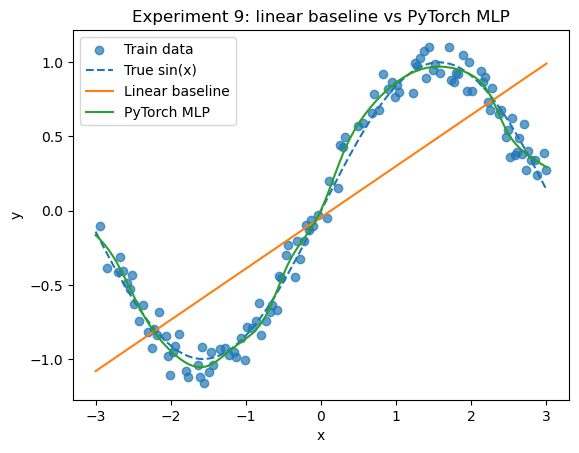

In [54]:
fig, ax = plt.subplots()

ax.scatter(x_train_np, y_train_np, label="Train data", alpha=0.7)
ax.plot(x_plot_np, y_clean_plot_np, linestyle="--", label="True sin(x)")
ax.plot(x_plot_np, y_linear_plot_np, label="Linear baseline")
ax.plot(x_plot_np, y_plot_np, label="PyTorch MLP")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Experiment 9: linear baseline vs PyTorch MLP")
ax.legend()

fig_path = FIGURE_DIR / "exp9_linear_baseline_vs_mlp.png"
fig.savefig(fig_path, dpi=200, bbox_inches="tight")

print("Saved figure to:", fig_path)
plt.show()

In [56]:
torch.manual_seed(0)

batch_model = SineMLP()
batch_loss_fn = nn.MSELoss()
batch_optimiser = optim.Adam(batch_model.parameters(), lr=1e-2)

batch_size = 32
num_epochs_batch = 3000

batch_train_loss_history = []
batch_val_loss_history = []

In [58]:
num_train = x_train.shape[0]

for epoch in range(num_epochs_batch):
    batch_model.train()

    # Shuffle training indices each epoch
    permutation = torch.randperm(num_train)

    epoch_losses = []

    for start in range(0, num_train, batch_size):
        batch_indices = permutation[start:start + batch_size]

        x_batch = x_train[batch_indices]
        y_batch = y_train[batch_indices]

        y_pred_batch = batch_model(x_batch)
        batch_loss = batch_loss_fn(y_pred_batch, y_batch)

        batch_optimiser.zero_grad()
        batch_loss.backward()
        batch_optimiser.step()

        epoch_losses.append(batch_loss.item())

    batch_model.eval()

    with torch.no_grad():
        y_pred_val_batch = batch_model(x_val)
        val_loss_batch = batch_loss_fn(y_pred_val_batch, y_val)

    batch_train_loss_history.append(np.mean(epoch_losses))
    batch_val_loss_history.append(val_loss_batch.item())

    if epoch % 500 == 0:
        print(
            "epoch:",
            epoch,
            "batch train loss:",
            batch_train_loss_history[-1],
            "val loss:",
            batch_val_loss_history[-1]
        )

epoch: 0 batch train loss: 0.23202740028500557 val loss: 0.22104640305042267
epoch: 500 batch train loss: 0.007593123475089669 val loss: 0.012051141820847988
epoch: 1000 batch train loss: 0.008326435345225036 val loss: 0.01421651802957058
epoch: 1500 batch train loss: 0.0069775908486917615 val loss: 0.013400095514953136
epoch: 2000 batch train loss: 0.006787314196117222 val loss: 0.014728734269738197
epoch: 2500 batch train loss: 0.006252519553527236 val loss: 0.015596956014633179


Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures/exp9_minibatch_loss_curve.png


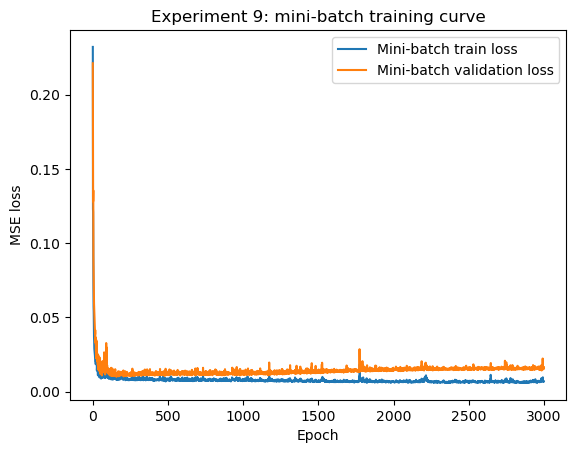

In [60]:
fig, ax = plt.subplots()

ax.plot(batch_train_loss_history, label="Mini-batch train loss")
ax.plot(batch_val_loss_history, label="Mini-batch validation loss")

ax.set_xlabel("Epoch")
ax.set_ylabel("MSE loss")
ax.set_title("Experiment 9: mini-batch training curve")
ax.legend()

fig_path = FIGURE_DIR / "exp9_minibatch_loss_curve.png"
fig.savefig(fig_path, dpi=200, bbox_inches="tight")

print("Saved figure to:", fig_path)
plt.show()